Nous commençons par charger le csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


df = pd.read_csv("telco_customer_churn.zip",compression='zip',sep=",")

Nous regardons a quoi ressemble la database.

In [2]:
print(df.info()) 
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Nous verifons si la data à déja été "nettoyer"

In [3]:
print("Nombre de doublons :", df.duplicated().sum())
print("Valeurs manquantes restantes :")
print(df.isnull().sum())

Nombre de doublons : 0
Valeurs manquantes restantes :
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Nous modifier le noms de colonnes en français.

In [4]:
noms_fr = {
    "customerID": "ID_Client",
    "gender": "Genre",
    "SeniorCitizen": "Client_Senior",
    "Partner": "Partenaire",
    "Dependents": "Personnes_a_charge",
    "tenure": "Anciennete",
    "PhoneService": "Service_Telephone",
    "MultipleLines": "Lignes_multiples",
    "InternetService": "Type_Internet",
    "OnlineSecurity": "Securite_en_ligne",
    "OnlineBackup": "Sauvegarde_en_ligne",
    "DeviceProtection": "Protection_appareil",
    "TechSupport": "Assistance_technique",
    "StreamingTV": "Streaming_TV",
    "StreamingMovies": "Streaming_Films",
    "Contract": "Type_contrat",
    "PaperlessBilling": "Facturation_electronique",
    "PaymentMethod": "Methode_paiement",
    "MonthlyCharges": "Facture_mensuelle",
    "TotalCharges": "Facture_totale",
    "Churn": "Resiliation"
}

df = df.rename(columns=noms_fr)

Nous allons maintenant modifier les differentes colonne pour pouvoir travailler dessus car pour l'instant elle sont en object ce qui les rends difficle à trvailler

Les colonnes Securite_en_ligne, Sauvegarde_en_ligne, Protection_appareil, Assistance_technique, Streaming_TV, Streaming_Films peuvent avoir comme valeur No internet service, or nous avons déjà la colonne Type_internet qui nous donne cette information. Nous allons donc nettoyer toutes ces colonnes pour modifier No internet service en No.

Deplus nous allons binariser chacunes de ces colonnes.

Oui = 1 et Non = 0


Nous modifions la colonne genre pour avoir 0 si c'est un homme et 1 si c'est une femme.
Nous modifions la colonne partner pour avoir 0 si la personne est seul et 1 si elle est en couple.

In [5]:
cols_internet = ["Securite_en_ligne", "Sauvegarde_en_ligne", "Protection_appareil",
                 "Assistance_technique", "Streaming_TV", "Streaming_Films"]

for col in cols_internet:
    df[col] = df[col].replace({"No internet service": "No"})
    df[col] = df[col].map({"Yes": 1, "No": 0})


Nous allons procéder à la même chose sur la colonne Lignes_multiples qui disposent de valeur No phone service alors que la colonne Service_telephone donne d"jà cette information.

In [6]:
df["Lignes_multiples"] = df["Lignes_multiples"].replace({"No phone service": "No"})
df["Lignes_multiples"] = df["Lignes_multiples"].map({"Yes": 1, "No": 0})

Nous allons maintenant binariser toutes les colonnes disposant de valeur Yes et No.

In [7]:
cols_binaire = ["Partenaire","Personnes_a_charge","Service_Telephone","Facturation_electronique","Resiliation"]

for col in cols_binaire:
    df[col] = df[col].map({"Yes": 1, "No": 0})

Puis nous passons à la colonne Genre que nous allons modifions de fassons à avoir 0 = Homme et 1 = Femme

In [8]:
df["Genre"] = df["Genre"].map({"Female": 1, "Male": 0})

In [9]:
cols_dum = ["Methode_paiement", "Type_Internet","Type_contrat"]

df["Type_Internet"] = df["Type_Internet"].replace({"No": "A"})

df = pd.get_dummies(df, columns=cols_dum, drop_first=True,dtype=int)

In [10]:
noms_fr2={
    "Methode_paiement_Bank transfer (automatic)": "Paiement_virement_auto",
    "Methode_paiement_Credit card (automatic)": "Paiement_carte_auto",
    "Methode_paiement_Electronic check": "Paiement_cheque_elec",
    "Methode_paiement_Mailed check": "Paiement_cheque_postal",
    "Type_Internet_Fiber optic": "Fibre_internet",
    "Type_Internet_DSL": "DSL",
    "Type_contrat_One year": "Contrat_1_an",
    "Type_contrat_Two year": "Contrat_2_ans"
}

df = df.rename(columns=noms_fr2)

Nous allons maintenant modifier la colonne Facture Totale pour la rendre type float.

On remarque que les colonnes qui ont comme valeur Nan , sont les colonne pour les client ayant une ancienneté de 0. 

Nous remplacons donc par 0 la valeur Nan.

In [11]:
df["Facture_totale"] = pd.to_numeric(df["Facture_totale"], errors="coerce")

#print(df[df["Facture_totale"].isnull() == True]["Anciennete"])

df["Facture_totale"] = df["Facture_totale"].fillna(0)

Pour notre modele de ML la colonne ID_Client ne sera pas utile. Nous pouvons donc la supprimer, de m^me nous allons enlever la colonne Resiliation pour la mettre dans une autre variable car ça sera notre variable d'entrainement.

In [12]:
X = df.drop(columns=["ID_Client", "Resiliation"])
y = df["Resiliation"]

Nous allons maintenant passer à la partie ML.

Pour cela nous allons tester 4 modeles pour selectionne celui que nous preferons.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Liste des modèles
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

# Dictionnaire pour stocker les résultats
results = {}

# Entraînement et évaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    Auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        "Accuracy": report["accuracy"],
        "Recall_1": report["1"]["recall"],
        "Precision_1": report["1"]["precision"],
        "F1_1": report["1"]["f1-score"],
        "AUC": Auc
    }

# Affichage
results_df = pd.DataFrame(results).T.sort_values(by="AUC", ascending=False)
print(results_df)

[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418
                     Accuracy  Recall_1  Precision_1      F1_1       AUC
Logistic Regression  0.751597  0.833780     0.519199  0.639918  0.862185
XGBoost              0.797729  0.522788     0.645695  0.577778  0.850664
LightGBM             0.806246  0.538874     0.665563  0.595556  0.849839
Random Forest        0.801278  0.455764     0.688259  0.548387  0.841243


D:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Nous choisissons le modele Logistic Regression car nous voulons maximiser la détéction de churn

Nous commencons par créer une pipeline

In [14]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, penalty="l2", solver="lbfgs"))
])



Nous allons maintenant entrainer le modele.

In [15]:
log_reg.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=5000))])

Nous voulons mainteant connaitre l'importance de chaque variables (poids) sur le churn . Nous commencons par extraire.

In [16]:
coeffs = log_reg.named_steps["clf"].coef_[0]
features = X_train.columns
coef_df = pd.DataFrame({"Feature": features, "Coefficient": coeffs})
coef_df["Impact"] = np.exp(coeffs)

Nous trions par valeur absolue pour avoir un classement en fonction de l'impact sur le chrun. (Positif ou négatif)

In [17]:
coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)

Puis nous voulons affihcer nous résulatat dans un diagramme. Ainsi que la liste des 10 variables qui ont le plus plus d'impacts.

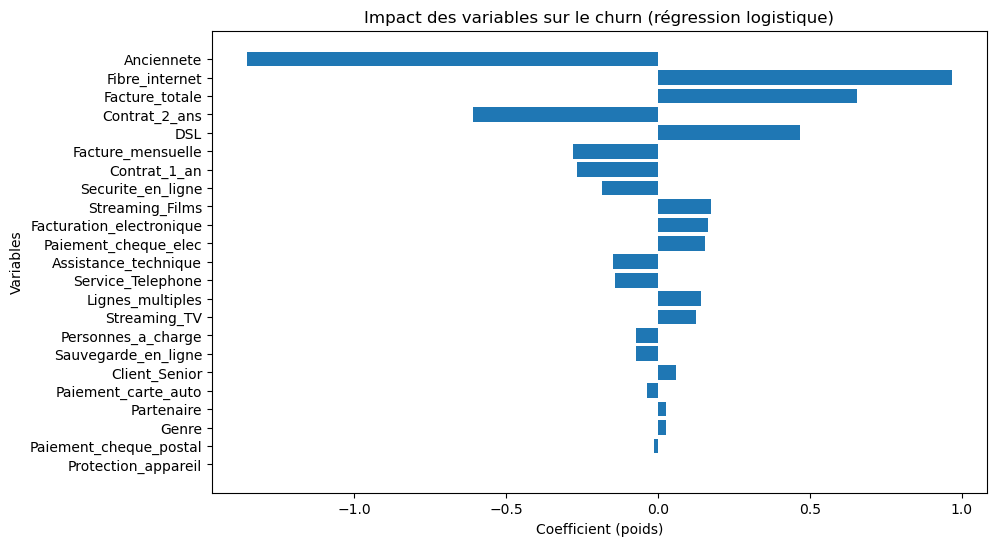

,Feature,Coefficient,Impact
4,Anciennete,-1.353324,0.258380
20,Fibre_internet,0.966282,2.628156
15,Facture_totale,0.653667,1.922578
22,Contrat_2_ans,-0.608529,0.544151
19,DSL,0.467602,1.596161
14,Facture_mensuelle,-0.281665,0.754527
21,Contrat_1_an,-0.267420,0.765352
7,Securite_en_ligne,-0.184329,0.831662
12,Streaming_Films,0.173218,1.189126
13,Facturation_electronique,0.164949,1.179333


In [25]:
plt.figure(figsize=(10,6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient (poids)")
plt.ylabel("Variables")
plt.title("Impact des variables sur le churn (régression logistique)")
plt.gca().invert_yaxis()
plt.show()

coef_df.head(20)

Nous voulons mainteant optimiser notre modèle de régréssion linéaire.

Nous commencons par définir nos hyperparametres.

In [19]:
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10], 
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear", "saga"] 
}



Puis nous allons tester chaques combinaisons pour choisir la meuilleur possible. Nous affichons apres cette combinaison et allons l'utiliser pour la suite.

In [20]:
grid = GridSearchCV(log_reg, param_grid, cv=5, scoring="recall", n_jobs=-1)
grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres:", grid.best_params_)
print("Meilleur score recall:", grid.best_score_)

best_model = grid.best_estimator_

Meilleurs hyperparamètres: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Meilleur score recall: 0.5427714604236343


Nous allons mainteantn affichzer la courbes ROC et la courbes Precission-Recall.

Pour cela nous commencons par récuperer les probabilité de prédiciton.

In [21]:
y_pred_proba = best_model.predict_proba(X_test)[:,1]

Nous povons ensuite tracer la courbe ROC 

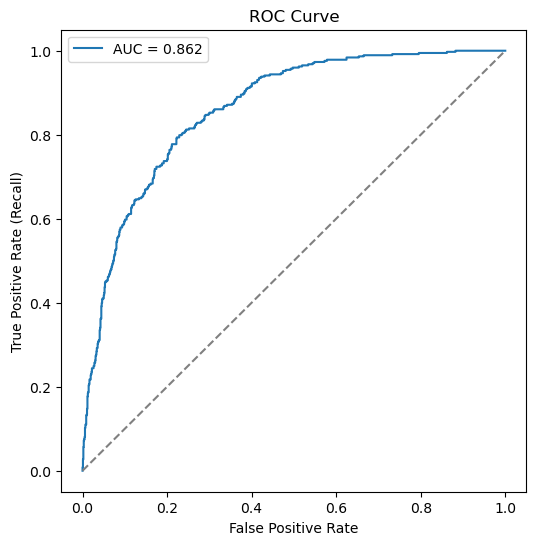

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--',color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()



Nous traconc ensuite la courbe Przecision recall.

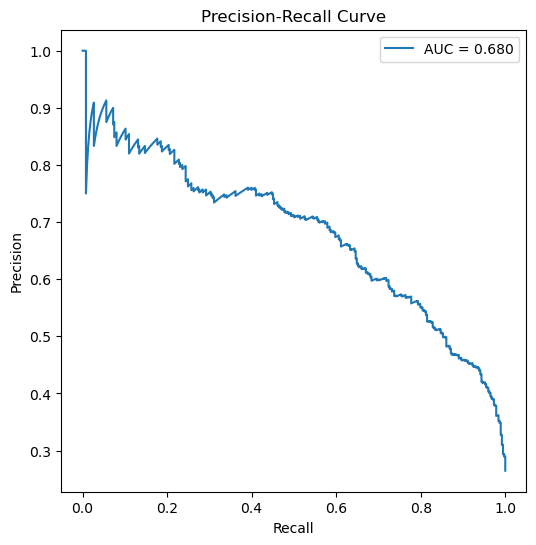

In [23]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Nous pouvons maintenant affihcer differences indicateur de performance de notre modele. Nous affichons une matrice de confusion, un rapport de classification ainsi que le socre AUC

In [24]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("AUC :", roc_auc)

Matrice de confusion :
[[933 103]
 [149 224]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

AUC : 0.8622317740950448
